# Quantium Analysis 2026
### author: Nicholas Chavez

Summary: This is an inventory analysis conducted on the vendor's potato chip stock, evaluating the performance of the potato chip inventory over a year.

In [44]:
# Pandas and Numpy imported for analysis
import pandas as pd
import numpy as np

In [45]:
# loaded needed dataframes for analysis
transactionData = pd.read_csv("C://Users//Nicho//Downloads//QuantiumAnalyis2026//QVI_transaction_data.csv")
customerData = pd.read_csv("C://Users//Nicho//Downloads//QuantiumAnalyis2026//QVI_purchase_behaviour.csv")

In [46]:
# Identify types of each column
## Note: Date needs to be altered to a date format
transactionData.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [47]:
# check customer data as well
customerData.dtypes # no apparent issues

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

In [48]:
# explore the dataframe
transactionData.head(10) # date seems to be in a numeric format instead of a clear date format

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [49]:
# exploring the date column to understand format
earliestdate = transactionData['DATE'].min()
latestdate = transactionData['DATE'].max()
print(f" Min: {earliestdate} \n Max: {latestdate} r") # 364 date might indicate a year timeframe

 Min: 43282 
 Max: 43646 r


In [50]:
# identifying unique values for each column:
# Note: Date has 364 unique date Numbers and the max-min difference is 364, indicating that the data columns follows a year format
transactionData.nunique() # further research indicates this format is likely Excel serial numbers, which can be translate to dates

DATE                 364
STORE_NBR            272
LYLTY_CARD_NBR     72637
TXN_ID            263127
PROD_NBR             114
PROD_NAME            114
PROD_QTY               6
TOT_SALES            112
dtype: int64

In [51]:
# Creating a copy for version control
transactionData2 = transactionData.copy()
transactionData2['DATE'] = pd.to_datetime(transactionData2['DATE'], unit='D', origin='1899-12-30') #
# Dates are to be interpreted as 43282 days passed since 1899-12-30 and so forth
transactionData2.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [52]:
transactionData2.dtypes # Data is now a date format

DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object

In [53]:
# exploring the date column under the new format
# note: the diff is not inclusive of the start date 2018-07-01 and is truly representing days since 2018-07-01
# this counts 2018-07-02 to 2019-06-30 (Fencepost Error)
earliestdate = transactionData2['DATE'].min()
latestdate = transactionData2['DATE'].max()
print(f" Min: {earliestdate} \n Max: {latestdate} \n diff: {latestdate - earliestdate} \n unique: { transactionData2['DATE'].nunique()}") 
# with this Fencepost Error noted, we can conclude that a day is missing from the dataset

 Min: 2018-07-01 00:00:00 
 Max: 2019-06-30 00:00:00 
 diff: 364 days 00:00:00 
 unique: 364


In [54]:
transactionData2.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [55]:
# Identifying the missing value
accurate_range = pd.date_range(start='2018-07-01', end='2019-06-30')
missing_date = accurate_range.difference(transactionData2['DATE'])
print(f"the missing date is: {missing_date}")

the missing date is: DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


In [56]:
transactionData2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [57]:
# Ensure store numbers are representative of actual locations
print(f"Stores: {transactionData2['STORE_NBR'].nunique()} \nMaxStoreNumber: {transactionData2['STORE_NBR'].max()} \nMinStoreNumber: {transactionData2['STORE_NBR'].min()}")
# There are 272 unique stores, and store numbers range from 1 to 272, indicating proper representation

Stores: 272 
MaxStoreNumber: 272 
MinStoreNumber: 1


In [58]:
# Produce QTY verification: numbers should be at the lowest 1
print(f"MinProductQuantity: {transactionData2['PROD_QTY'].min()} \nMaxProductQuantity: {transactionData2['PROD_QTY'].max()}")

MinProductQuantity: 1 
MaxProductQuantity: 200


In [59]:
# Examining product names to ensure they are correct
transactionData2['PROD_NAME'].describe()
# we are looking at 114 different products

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [60]:
transactionData2['PROD_NAME'].value_counts()
# woolworths medium Salsa, indicates non-chip products may be included

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Dorito Corn Chp     Supreme 380g            3185
Pringles Sweet&Spcy BBQ 134g                3177
Infuzions BBQ Rib   Prawn Crackers 110g     3174
Tyrrells C

In [61]:
# Ensuring all products are chips
# Split all unique product names into individual words
product_words = (
    transactionData2['PROD_NAME']
    .unique()                          # get unique product names
    .tolist()                          # convert to list
)

# Join all product names into one string, then split into individual words
product_words = pd.Series(
    ' '.join(product_words).split()
)

print(product_words.value_counts())

175g                  26
Chips                 21
150g                  19
&                     17
Smiths                16
Crinkle               14
Cut                   14
Kettle                13
Salt                  12
Cheese                12
Original              10
Salsa                  9
Chip                   9
Doritos                9
Pringles               8
134g                   8
170g                   8
Corn                   8
165g                   8
RRD                    8
WW                     7
Chicken                7
110g                   7
300g                   6
Sea                    6
Sour                   6
Thins                  5
Vinegar                5
Chilli                 5
Thinly                 5
Crisps                 5
Cream                  4
Rock                   4
Deli                   4
Supreme                4
Infuzions              4
Natural                4
Red                    4
330g                   4
Dip                    3


In [62]:
import re

# Remove digits
product_words = product_words[~product_words.str.contains(r'\d', regex=True)]

# Remove special characters (keep only alphabetic words)
product_words = product_words[product_words.str.match(r'^[a-zA-Z]+$')]

# View word frequency high to low
word_freq = product_words.value_counts().reset_index()
word_freq.columns = ['WORD', 'COUNT']
print(word_freq)

                WORD  COUNT
0              Chips     21
1             Smiths     16
2            Crinkle     14
3                Cut     14
4             Kettle     13
5               Salt     12
6             Cheese     12
7           Original     10
8            Doritos      9
9               Chip      9
10             Salsa      9
11              Corn      8
12          Pringles      8
13               RRD      8
14           Chicken      7
15                WW      7
16               Sea      6
17              Sour      6
18            Thinly      5
19            Crisps      5
20           Vinegar      5
21             Thins      5
22            Chilli      5
23           Supreme      4
24              Deli      4
25              Rock      4
26               Red      4
27             Cream      4
28           Natural      4
29         Infuzions      4
30              Mild      3
31               Old      3
32               Dip      3
33          Tostitos      3
34            Tomato

In [63]:
pd.set_option('display.max_rows', None)
word_freq

,WORD,COUNT
0,Chips,21
1,Smiths,16
2,Crinkle,14
3,Cut,14
4,Kettle,13
5,Salt,12
6,Cheese,12
7,Original,10
8,Doritos,9
9,Chip,9


In [64]:
salsas = transactionData2[transactionData2['PROD_NAME'].str.contains("Salsa") == True]
salsas['PROD_NAME'].unique()
# All need to be removed, other than Smith's Crinkle Cut  Tomato Salsa 150g and Red Rock Deli SR Salsa & Mzzrlla, which refers to an actual chip

array(['Old El Paso Salsa   Dip Tomato Mild 300g',
       'Red Rock Deli SR    Salsa & Mzzrlla 150g',
       'Smiths Crinkle Cut  Tomato Salsa 150g',
       'Doritos Salsa       Medium 300g',
       'Old El Paso Salsa   Dip Chnky Tom Ht300g',
       'Woolworths Mild     Salsa 300g',
       'Old El Paso Salsa   Dip Tomato Med 300g',
       'Woolworths Medium   Salsa 300g', 'Doritos Salsa Mild  300g'],
      dtype=object)

In [127]:
'''
transactionData2[transactionData2['PROD_NAME'].str.contains("Mac") == True]: Checked and good

transactionData2[transactionData2['PROD_NAME'].str.contains("RRD") == True]: Check, Red Rock Deli Brand

transactionData2[transactionData2['PROD_NAME'].str.contains("Chicken") == True]: Checked, Both WW and Chicken are good

Note: Red Rock Deli and RDD are the same, need to check abbreviations

Check = transactionData2[transactionData2['PROD_NAME'].str.contains("Dip") == True]
Check['PROD_NAME'].unique()

Old El Paso Salsa Dip must be removed; Smith's Crinkle Cut  French Onion Dip refers to an actual chip 
Because I am noticing a trend with Old El Paso, I am going to isolate specified rows 

Old_El = transactionData2[transactionData2['PROD_NAME'].str.contains("Old") == True]
Old_El['PROD_NAME'].unique()
Old El Paso is only connected to Salsa

Doritos_salsa = transactionData2[transactionData2['PROD_NAME'].str.contains("Doritos Salsa") == True]
Doritos_salsa['PROD_NAME'].unique()
Doritos = transactionData2[transactionData2['PROD_NAME'].str.contains("Doritos") == True]
Doritos['PROD_NAME'].unique() 

Woolworths = transactionData2[transactionData2['PROD_NAME'].str.contains("Woolworths") == True]
Woolworths['PROD_NAME'].unique()

Woolworths does not make potato chips; therefore can be removed

corn = transactionData2[transactionData2['PROD_NAME'].str.contains("Corn") == True]
corn['PROD_NAME'].unique()

All, including corn, do not relate to potato chips

WW = transactionData2[transactionData2['PROD_NAME'].str.contains("WW") == True]
WW['PROD_NAME'].unique()

WW is fine, removing Corn cleans WW rows

Strws = transactionData2[transactionData2['PROD_NAME'].str.contains("Strws") == True]
Strws['PROD_NAME'].unique()

Straws = transactionData2[transactionData2['PROD_NAME'].str.contains("Straws") == True]
Straws['PROD_NAME'].unique()

Tostitos = transactionData2[transactionData2['PROD_NAME'].str.contains("Tostitos") == True]
Tostitos['PROD_NAME'].unique()

Cheetos = transactionData2[transactionData2['PROD_NAME'].str.contains("Cheetos") == True]
Cheetos['PROD_NAME'].unique()

Bolognese = transactionData2[transactionData2['PROD_NAME'].str.contains("Bolognese") == True]
Bolognese['PROD_NAME'].unique()
'''
Keyword_removed = ['Old', 'Doritos', 'Whlgrn','Woolworths', 'Crackers','Corn', 'Strws', 'Tostitos', 'Balls','Puffs','Tortilla','Twisties','Btroot','Cheezels','Whlegrn','CCs','Grain']
Cleaned_PC = transactionData2[transactionData2['PROD_NAME'].str.contains('|'.join(Keyword_removed), case=False, na=False) == False]
Cleaned_PC['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Pringles Barbeque   134g                    3210
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Pringles Sweet&Spcy BBQ 134g                3177
Tyrrells Crisps     Lightly Salted 165g     3174
Kettle Sea Salt     And Vinegar 175g        3173
Pringles SourCream  Onion 134g              3162
Kettle Original 175g                        3159
Cobs Popd Sour Crm  &Chives Chips 110g      3159
Pringles Original   Crisps 134g             3157
Kettle Hon

In [128]:
Cleaned_PC.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7


In [129]:
Cleaned_PC.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,162282,162282.000000,1.622820e+05,1.622820e+05,162282.000000,162282.000000,162282.000000
mean,2018-12-30 04:30:29.348911104,135.034249,1.354939e+05,1.351127e+05,55.601508,1.904574,7.084560
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.005925e+04,6.783250e+04,26.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.302610e+05,1.347315e+05,53.000000,2.000000,6.600000
75%,2019-03-31 00:00:00,203.000000,2.030340e+05,2.024145e+05,85.000000,2.000000,8.400000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.663024,8.028987e+04,7.808107e+04,34.599058,0.345488,2.397961


In [130]:
# Filter Data to find outliers
# Produce QTY verification: numbers should be at the lowest 1
print(f"MinProductQuantity: {Cleaned_PC['PROD_QTY'].min()} \nMaxProductQuantity: {Cleaned_PC['PROD_QTY'].max()}")

MinProductQuantity: 1 
MaxProductQuantity: 5


In [131]:
# Produce QTY verification: numbers should be at the lowest 1
print(f"MinProductQuantity: {transactionData2['PROD_QTY'].min()} \nMaxProductQuantity: {transactionData2['PROD_QTY'].max()}")

MinProductQuantity: 1 
MaxProductQuantity: 200


In [132]:
transactionData2[ transactionData2['PROD_QTY'] == 200 ]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [133]:
'''
The maximum we seen ealier were corn chips not potato, so it was removed from analysis, however this seemed to be the only outlier.
Based on the purchase data and these two being the same amount, this might be for commerical use.
'''

'\nThe maximum we seen ealier were corn chips not potato, so it was removed from analysis, however this seemed to be the only outlier.\nBased on the purchase data and these two being the same amount, this might be for commerical use.\n'

In [134]:
Cleaned_PC.nunique()

print(f"""
Cleaned Data Summary:
---------------------
Time Period   : 1 year of data
Products      : {Cleaned_PC['PROD_NAME'].nunique()} unique chip flavors/brands
Stores        : {Cleaned_PC['STORE_NBR'].nunique()} unique stores
Customers     : {Cleaned_PC['LYLTY_CARD_NBR'].nunique()} unique customers
Transactions  : {Cleaned_PC['TXN_ID'].nunique()} unique transactions
""")


Cleaned Data Summary:
---------------------
Time Period   : 1 year of data
Products      : 73 unique chip flavors/brands
Stores        : 269 unique stores
Customers     : 62184 unique customers
Transactions  : 161657 unique transactions



In [135]:
customerData.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [158]:
customerData.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [160]:
customerData['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [161]:
customerData['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [162]:
customerData.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [136]:
concat_data = Cleaned_PC.merge(customerData, on = 'LYLTY_CARD_NBR')

In [137]:
concat_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
2,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget


In [138]:
concat_data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [139]:
import matplotlib.pyplot as plt

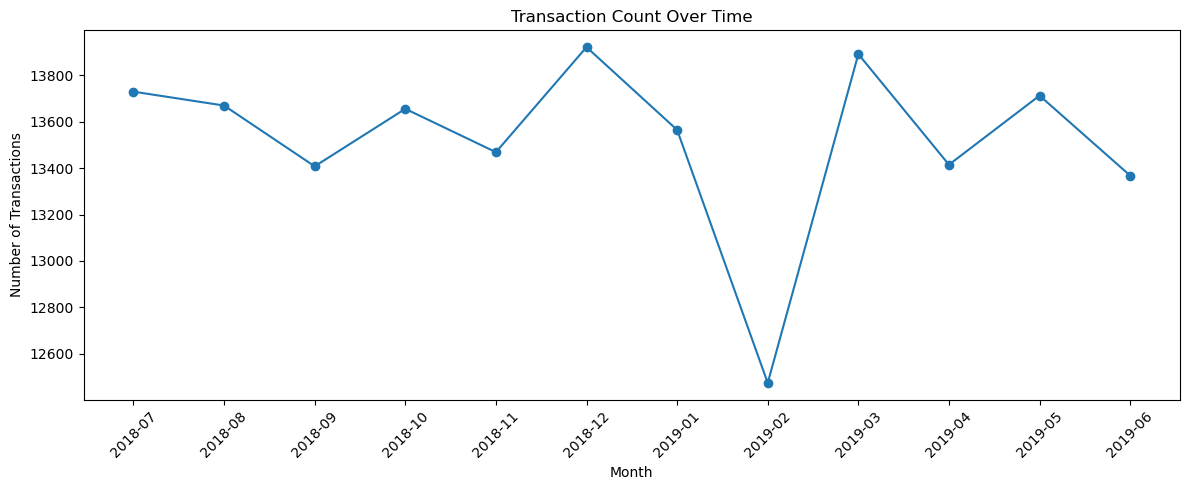

In [140]:
concat_data['DATE'] = pd.to_datetime(concat_data['DATE'])
concat_data = concat_data.sort_values('DATE')

monthly_counts = concat_data.groupby(concat_data['DATE'].dt.to_period('M')).size().reset_index(name='count')
monthly_counts['DATE'] = monthly_counts['DATE'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_counts['DATE'], monthly_counts['count'], marker='o')
plt.title('Transaction Count Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### PACK SIZE

In [141]:
concat_data['PACK_SIZE'] = concat_data['PROD_NAME'].str.extract(r'(\d+)').astype(int)

In [142]:
print(f"Max pack size: {concat_data['PACK_SIZE'].max()} \nMin pack size: {concat_data['PACK_SIZE'].min()}")

Max pack size: 380 
Min pack size: 70


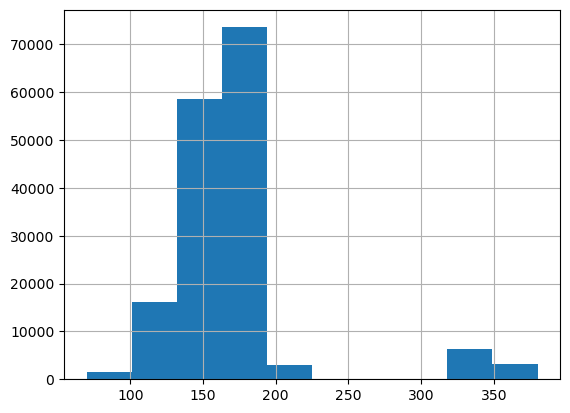

In [143]:
concat_data['PACK_SIZE'].hist()
plt.show()

### BRANDS

In [144]:
concat_data['BRAND'] = concat_data['PROD_NAME'].str.split().str[0]

In [152]:
concat_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND
151499,2018-07-01,113,113012,115430,103,RRD Steak & Chimuchurri 150g,2,5.4,YOUNG SINGLES/COUPLES,Mainstream,150,Red Rock Deli
46995,2018-07-01,156,156011,156670,14,Smiths Crnkle Chip Orgnl Big Bag 380g,2,11.8,OLDER FAMILIES,Premium,380,Smiths
68339,2018-07-01,165,165354,167050,63,Kettle 135g Swt Pot Sea Salt,2,8.4,OLDER SINGLES/COUPLES,Mainstream,135,Kettle
20417,2018-07-01,10,10055,9352,36,Kettle Chilli 175g,2,10.8,OLDER FAMILIES,Budget,175,Kettle
20435,2018-07-01,10,10111,9693,82,Smith Crinkle Cut Mac N Cheese 150g,2,5.2,OLDER FAMILIES,Budget,150,Smiths


In [153]:
concat_data['BRAND'].unique()

array(['Red Rock Deli', 'Smiths', 'Kettle', 'Woolworths', 'Thins',
       'Tyrrells', 'Pringles', 'Infuzions', 'Cobs Popcorn',
       'Natural Chip Co', 'French Fries', 'Nice & Natural',
       'Burger Rings'], dtype=object)

In [149]:
brand_mapping = {
    'NCC'       : 'Nice & Natural',
    'Thins'     : 'Thins',
    'WW'        : 'Woolworths',
    'Smiths'    : 'Smiths',
    'Kettle'    : 'Kettle',
    'French'    : 'French Fries',
    'Cobs'      : 'Cobs Popcorn',
    'Infuzions' : 'Infuzions',
    'RRD'       : 'Red Rock Deli',
    'Pringles'  : 'Pringles',
    'Infzns'    : 'Infuzions',       # likely a typo/duplicate
    'Tyrrells'  : 'Tyrrells',
    'Smith'     : 'Smiths',          # likely a typo/duplicate
    'Red'       : 'Red Rock Deli',   # likely part of Red Rock Deli
    'Burger'    : 'Burger Rings',
    'Natural'   : 'Natural Chip Co',
    'Snbts'     : 'Sunbites'
}

# Apply it
concat_data['BRAND'] = concat_data['BRAND'].map(brand_mapping)

In [154]:
concat_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND
151499,2018-07-01,113,113012,115430,103,RRD Steak & Chimuchurri 150g,2,5.4,YOUNG SINGLES/COUPLES,Mainstream,150,Red Rock Deli
46995,2018-07-01,156,156011,156670,14,Smiths Crnkle Chip Orgnl Big Bag 380g,2,11.8,OLDER FAMILIES,Premium,380,Smiths
68339,2018-07-01,165,165354,167050,63,Kettle 135g Swt Pot Sea Salt,2,8.4,OLDER SINGLES/COUPLES,Mainstream,135,Kettle
20417,2018-07-01,10,10055,9352,36,Kettle Chilli 175g,2,10.8,OLDER FAMILIES,Budget,175,Kettle
20435,2018-07-01,10,10111,9693,82,Smith Crinkle Cut Mac N Cheese 150g,2,5.2,OLDER FAMILIES,Budget,150,Smiths


In [172]:
concat_data['PRICE'] = concat_data['TOT_SALES'] / concat_data['PROD_QTY']
concat_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND,PRICE
151499,2018-07-01,113,113012,115430,103,RRD Steak & Chimuchurri 150g,2,5.4,YOUNG SINGLES/COUPLES,Mainstream,150,Red Rock Deli,2.7
46995,2018-07-01,156,156011,156670,14,Smiths Crnkle Chip Orgnl Big Bag 380g,2,11.8,OLDER FAMILIES,Premium,380,Smiths,5.9
68339,2018-07-01,165,165354,167050,63,Kettle 135g Swt Pot Sea Salt,2,8.4,OLDER SINGLES/COUPLES,Mainstream,135,Kettle,4.2
20417,2018-07-01,10,10055,9352,36,Kettle Chilli 175g,2,10.8,OLDER FAMILIES,Budget,175,Kettle,5.4
20435,2018-07-01,10,10111,9693,82,Smith Crinkle Cut Mac N Cheese 150g,2,5.2,OLDER FAMILIES,Budget,150,Smiths,2.6


## Distribution of customers by each group

In [163]:
# Life Stage Ranked and Count of Customers in each group
concat_data.groupby('LIFESTAGE').size().reset_index(name = 'count').sort_values('count',ascending = False)
# Older Singles/couples spend the most on potato chips

,LIFESTAGE,count
3,OLDER SINGLES/COUPLES,33206
2,OLDER FAMILIES,30300
4,RETIREES,30252
5,YOUNG FAMILIES,26880
6,YOUNG SINGLES/COUPLES,22078
0,MIDAGE SINGLES/COUPLES,15359
1,NEW FAMILIES,4207


In [164]:
# Premium Ranked and count of customers in each group
concat_data.groupby('PREMIUM_CUSTOMER').size().reset_index(name = 'count').sort_values('count',ascending = False)
# Mainstream spends the most on potato chips

,PREMIUM_CUSTOMER,count
1,Mainstream,61982
0,Budget,57323
2,Premium,42977


In [165]:
# Combined ranked, Premium, and Life Stage
concat_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).size().reset_index(name = 'count').sort_values('count',ascending = False)

,LIFESTAGE,PREMIUM_CUSTOMER,count
6,OLDER FAMILIES,Budget,14426
13,RETIREES,Mainstream,13041
19,YOUNG SINGLES/COUPLES,Mainstream,12362
15,YOUNG FAMILIES,Budget,11701
9,OLDER SINGLES/COUPLES,Budget,11254
10,OLDER SINGLES/COUPLES,Mainstream,11181
11,OLDER SINGLES/COUPLES,Premium,10771
12,RETIREES,Budget,9211
7,OLDER FAMILIES,Mainstream,8865
14,RETIREES,Premium,8000


### Distribution of Sales by each group

In [166]:
# Combined Group
concat_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,101776.1
13,RETIREES,Mainstream,91649.1
19,YOUNG SINGLES/COUPLES,Mainstream,90420.9
15,YOUNG FAMILIES,Budget,82752.3
9,OLDER SINGLES/COUPLES,Budget,81277.1
10,OLDER SINGLES/COUPLES,Mainstream,79093.6
11,OLDER SINGLES/COUPLES,Premium,77735.2
12,RETIREES,Budget,66493.3
7,OLDER FAMILIES,Mainstream,62559.2
14,RETIREES,Premium,57967.7


In [167]:
# Member Status Only
concat_data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,PREMIUM_CUSTOMER,TOT_SALES
1,Mainstream,442514.7
0,Budget,403741.3
2,Premium,303440.5


In [168]:
# Lifestage only
concat_data.groupby('LIFESTAGE')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,LIFESTAGE,TOT_SALES
3,OLDER SINGLES/COUPLES,238105.9
4,RETIREES,216110.1
2,OLDER FAMILIES,213527.8
5,YOUNG FAMILIES,189622.6
6,YOUNG SINGLES/COUPLES,153063.2
0,MIDAGE SINGLES/COUPLES,109593.8
1,NEW FAMILIES,29673.1


### Quantity of Chips

In [169]:
# Combined Group
concat_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index().sort_values('PROD_QTY', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY
6,OLDER FAMILIES,Budget,28052
13,RETIREES,Mainstream,24560
19,YOUNG SINGLES/COUPLES,Mainstream,22866
15,YOUNG FAMILIES,Budget,22721
9,OLDER SINGLES/COUPLES,Budget,21541
10,OLDER SINGLES/COUPLES,Mainstream,21341
11,OLDER SINGLES/COUPLES,Premium,20601
12,RETIREES,Budget,17421
7,OLDER FAMILIES,Mainstream,17272
16,YOUNG FAMILIES,Mainstream,15468


In [170]:
# Member Type
concat_data.groupby('PREMIUM_CUSTOMER')['PROD_QTY'].sum().reset_index().sort_values('PROD_QTY', ascending=False)

,PREMIUM_CUSTOMER,PROD_QTY
1,Mainstream,117786
0,Budget,109388
2,Premium,81904


In [171]:
# Lifestage
concat_data.groupby('LIFESTAGE')['PROD_QTY'].sum().reset_index().sort_values('PROD_QTY', ascending=False)

,LIFESTAGE,PROD_QTY
3,OLDER SINGLES/COUPLES,63483
2,OLDER FAMILIES,58966
4,RETIREES,57204
5,YOUNG FAMILIES,52156
6,YOUNG SINGLES/COUPLES,40329
0,MIDAGE SINGLES/COUPLES,29153
1,NEW FAMILIES,7787


### Average Chip Price

In [174]:
# Combined
concat_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE'].mean().reset_index().sort_values('PRICE', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,PRICE
19,YOUNG SINGLES/COUPLES,Mainstream,3.946174
1,MIDAGE SINGLES/COUPLES,Mainstream,3.880148
5,NEW FAMILIES,Premium,3.813116
3,NEW FAMILIES,Budget,3.810033
12,RETIREES,Budget,3.808886
14,RETIREES,Premium,3.803925
11,OLDER SINGLES/COUPLES,Premium,3.768248
4,NEW FAMILIES,Mainstream,3.768085
9,OLDER SINGLES/COUPLES,Budget,3.767318
13,RETIREES,Mainstream,3.723541


In [175]:
# membership
concat_data.groupby('PREMIUM_CUSTOMER')['PRICE'].mean().reset_index().sort_values('PRICE', ascending=False)

,PREMIUM_CUSTOMER,PRICE
1,Mainstream,3.754300
2,Premium,3.699283
0,Budget,3.685155


In [176]:
# Lifestage
concat_data.groupby('LIFESTAGE')['PRICE'].mean().reset_index().sort_values('PRICE', ascending=False)

,LIFESTAGE,PRICE
1,NEW FAMILIES,3.796672
6,YOUNG SINGLES/COUPLES,3.777267
4,RETIREES,3.770784
0,MIDAGE SINGLES/COUPLES,3.753164
3,OLDER SINGLES/COUPLES,3.745052
5,YOUNG FAMILIES,3.636907
2,OLDER FAMILIES,3.621231


Mainstream midage and young singles and couples are more willing to pay more per
packet of chips compared to their budget and premium counterparts. This may be due
to premium shoppers being more likely to buy healthy snacks and when they buy
chips, this is mainly for entertainment purposes rather than their own consumption.
This is also supported by there being fewer premium midage and young singles and
couples buying chips compared to their mainstream counterparts.

In [177]:
concat_data[concat_data['PREMIUM_CUSTOMER'] == 'Premium'].groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).size().reset_index(name = 'count').sort_values('count',ascending = False)

,LIFESTAGE,PREMIUM_CUSTOMER,count
3,OLDER SINGLES/COUPLES,Premium,10771
4,RETIREES,Premium,8000
5,YOUNG FAMILIES,Premium,7214
2,OLDER FAMILIES,Premium,7009
0,MIDAGE SINGLES/COUPLES,Premium,5084
6,YOUNG SINGLES/COUPLES,Premium,3946
1,NEW FAMILIES,Premium,953


As the difference in average price per unit isn't large, we can check if this difference is statistically different.

In [178]:
from scipy import stats

# Filter groups
mainstream_midage = concat_data[
    (concat_data['PREMIUM_CUSTOMER'] == 'Mainstream') & 
    (concat_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES')
]['PRICE']

budget_premium_midage = concat_data[
    (concat_data['PREMIUM_CUSTOMER'].isin(['Premium', 'Budget'])) & 
    (concat_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES')
]['PRICE']

# T-test for Midage Singles/Couples
t_stat, p_value = stats.ttest_ind(mainstream_midage, budget_premium_midage)
print(f"Midage Singles/Couples — t-stat: {t_stat:.4f}, p-value: {p_value:.4f}")


# Filter groups
mainstream_young = concat_data[
    (concat_data['PREMIUM_CUSTOMER'] == 'Mainstream') & 
    (concat_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')
]['PRICE']

budget_premium_young = concat_data[
    (concat_data['PREMIUM_CUSTOMER'].isin(['Premium', 'Budget'])) & 
    (concat_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')
]['PRICE']

# T-test for Young Singles/Couples
t_stat, p_value = stats.ttest_ind(mainstream_young, budget_premium_young)
print(f"Young Singles/Couples — t-stat: {t_stat:.4f}, p-value: {p_value:.4f}")

Midage Singles/Couples — t-stat: 14.2035, p-value: 0.0000
Young Singles/Couples — t-stat: 27.8544, p-value: 0.0000


In [179]:
print("=== Midage Singles/Couples ===")
print(f"Mainstream mean price:      {mainstream_midage.mean():.4f}")
print(f"Budget/Premium mean price:  {budget_premium_midage.mean():.4f}")

print("\n=== Young Singles/Couples ===")
print(f"Mainstream mean price:      {mainstream_young.mean():.4f}")
print(f"Budget/Premium mean price:  {budget_premium_young.mean():.4f}")

=== Midage Singles/Couples ===
Mainstream mean price:      3.8801
Budget/Premium mean price:  3.6423

=== Young Singles/Couples ===
Mainstream mean price:      3.9462
Budget/Premium mean price:  3.5624


The t-test results in a p-value < 0.01, i.e., the unit price for mainstream young and mid-aged singles and couples is significantly higher than that of budget or premium, young and middle-aged singles and couples.

### Deep Drive into segments: Older Families Budget

In [180]:
segment_1 = concat_data[(concat_data['PREMIUM_CUSTOMER'] == 'Budget')&(concat_data['LIFESTAGE'] == 'OLDER FAMILIES')].copy()
segment_1.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND,PRICE
20417,2018-07-01,10,10055,9352,36,Kettle Chilli 175g,2,10.8,OLDER FAMILIES,Budget,175,Kettle,5.4
20435,2018-07-01,10,10111,9693,82,Smith Crinkle Cut Mac N Cheese 150g,2,5.2,OLDER FAMILIES,Budget,150,Smiths,2.6
31498,2018-07-01,219,219154,218894,43,Smith Crinkle Cut Bolognese 150g,2,5.2,OLDER FAMILIES,Budget,150,Smiths,2.6
20234,2018-07-01,5,5085,4863,11,RRD Pc Sea Salt 165g,2,6.0,OLDER FAMILIES,Budget,165,Red Rock Deli,3.0
21682,2018-07-01,39,39224,36000,37,Smiths Thinly Swt Chli&S/Cream175G,2,6.0,OLDER FAMILIES,Budget,175,Smiths,3.0


In [183]:
# Which brand is most purchased in the most transactions
segment_1.groupby('BRAND').size().reset_index(name = 'count').sort_values('count',ascending = False)

,BRAND,count
9,Smiths,3093
4,Kettle,2563
7,Pringles,1996
8,Red Rock Deli,1857
10,Thins,1171
12,Woolworths,773
1,Cobs Popcorn,760
3,Infuzions,682
5,Natural Chip Co,576
11,Tyrrells,489


In [192]:
# Which brand sold the most units
segment_1.groupby('BRAND')['PROD_QTY'].sum().reset_index().sort_values('PROD_QTY', ascending=False)

,BRAND,PROD_QTY
9,Smiths,5999
4,Kettle,5008
7,Pringles,3865
8,Red Rock Deli,3604
10,Thins,2278
12,Woolworths,1510
1,Cobs Popcorn,1489
3,Infuzions,1328
5,Natural Chip Co,1122
11,Tyrrells,953


In [184]:
# Which brand is the most profitable for this segment
segment_1.groupby('BRAND')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,BRAND,TOT_SALES
4,Kettle,25231.6
9,Smiths,21651.1
7,Pringles,14300.5
8,Red Rock Deli,10162.2
10,Thins,7517.4
1,Cobs Popcorn,5658.2
3,Infuzions,4660.0
11,Tyrrells,4002.6
5,Natural Chip Co,3366.0
12,Woolworths,2749.2


In [186]:
segment_1.groupby('BRAND')['PRICE'].mean().reset_index().sort_values('PRICE', ascending=False)

,BRAND,PRICE
4,Kettle,5.037924
11,Tyrrells,4.200000
1,Cobs Popcorn,3.800000
7,Pringles,3.700000
9,Smiths,3.611219
3,Infuzions,3.508504
10,Thins,3.300000
2,French Fries,3.000000
5,Natural Chip Co,3.000000
6,Nice & Natural,3.000000


In [195]:
segment_1.groupby('PACK_SIZE')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,PACK_SIZE,TOT_SALES
8,175,34346.5
4,150,16403.8
2,134,14300.5
1,110,9655.8
6,165,8316.6
11,330,6150.3
7,170,4312.3
12,380,2991.3
3,135,2213.4
5,160,1128.6


Older Families Budget Insight: Although Smith's sold the most to Budget Older Families, Kettle generated the most revenue. Despite lower sales volume, Kettle's higher revenue suggests stronger brand value per unit, indicating a customer segment willing to pay a premium. This higher price point, however, appears to suppress overall demand. A controlled price promotion on Kettle would allow the business to measure price elasticity and determine whether reducing price drives enough volume to offset the margin reduction, ultimately helping to identify whether price or preference is the primary driver of Kettle's lower unit sales. Furthermore, 175-gram size bags generate the most profit.

### Deep dive into segments: Mainstream, young singles/couples

In [187]:
segment_2 = concat_data[(concat_data['PREMIUM_CUSTOMER'] == 'Mainstream')&(concat_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')].copy()
segment_2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND,PRICE
151499,2018-07-01,113,113012,115430,103,RRD Steak & Chimuchurri 150g,2,5.4,YOUNG SINGLES/COUPLES,Mainstream,150,Red Rock Deli,2.7
151667,2018-07-01,116,116179,120232,81,Pringles Original Crisps 134g,2,7.4,YOUNG SINGLES/COUPLES,Mainstream,134,Pringles,3.7
151329,2018-07-01,109,109063,110536,98,NCC Sour Cream & Garden Chives 175g,2,6.0,YOUNG SINGLES/COUPLES,Mainstream,175,Nice & Natural,3.0
149211,2018-07-01,59,59307,55832,17,Kettle Sensations BBQ&Maple 150g,2,9.2,YOUNG SINGLES/COUPLES,Mainstream,150,Kettle,4.6
149279,2018-07-01,61,61145,57698,11,RRD Pc Sea Salt 165g,2,6.0,YOUNG SINGLES/COUPLES,Mainstream,165,Red Rock Deli,3.0


In [188]:
# Which brand is purchased during the most transactions
segment_2.groupby('BRAND').size().reset_index(name = 'count').sort_values('count',ascending = False)

,BRAND,count
4,Kettle,2949
7,Pringles,2315
9,Smiths,1988
10,Thins,1166
8,Red Rock Deli,969
1,Cobs Popcorn,864
3,Infuzions,657
11,Tyrrells,619
5,Natural Chip Co,321
12,Woolworths,301


In [193]:
# Which brand sold the most units
segment_2.groupby('BRAND')['PROD_QTY'].sum().reset_index().sort_values('PROD_QTY', ascending=False)

,BRAND,PROD_QTY
4,Kettle,5497
7,Pringles,4326
9,Smiths,3609
10,Thins,2187
8,Red Rock Deli,1753
1,Cobs Popcorn,1617
3,Infuzions,1227
11,Tyrrells,1143
5,Natural Chip Co,578
12,Woolworths,548


In [190]:
# Which brand is the most profitable for this segment
segment_2.groupby('BRAND')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,BRAND,TOT_SALES
4,Kettle,27718.6
7,Pringles,16006.2
9,Smiths,15265.7
10,Thins,7217.1
1,Cobs Popcorn,6144.6
8,Red Rock Deli,4958.1
11,Tyrrells,4800.6
3,Infuzions,4508.6
5,Natural Chip Co,1734.0
12,Woolworths,998.6


In [191]:
segment_2.groupby('BRAND')['PRICE'].mean().reset_index().sort_values('PRICE', ascending=False)

,BRAND,PRICE
4,Kettle,5.042455
9,Smiths,4.205936
11,Tyrrells,4.200000
1,Cobs Popcorn,3.800000
7,Pringles,3.700000
3,Infuzions,3.665753
10,Thins,3.300000
2,French Fries,3.000000
5,Natural Chip Co,3.000000
6,Nice & Natural,3.000000


In [196]:
segment_2.groupby('PACK_SIZE')['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)

,PACK_SIZE,TOT_SALES
8,175,29879.4
2,134,16006.2
4,150,11912.9
1,110,10389.2
6,165,7050.6
11,330,6378.3
12,380,3516.4
3,135,2247.0
7,170,1896.6
5,160,440.8


Mainstream Young Singles/Couples Insight: Kettle led across all key metrics; unit sales, total revenue. Price was consistent with findings across other segments. Unlike Budget Older Families, who showed sensitivity to Kettle's premium pricing, Mainstream Young Singles/Couples appear less price sensitive, willing to pay a premium for Kettle despite cheaper alternatives like Smiths being available. This is further supported by Kettle generating more revenue from Mainstream Young Singles/Couples than from Budget Older Families, suggesting that disposable income and lifestyle play a significant role in purchasing decisions. Notably, Pringles also ranked above Smiths in this segment, reinforcing the pattern that Mainstream Young Singles/Couples gravitate toward premium or well-known brands over value options. Pack size remained consistent with both segments.

In [197]:
concat_data.to_csv('ChipDataCleaned.csv', index=False, encoding='utf-8-sig', sep=',')